In [1]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import pip
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
import linearmodels as lm
from linearmodels import PanelOLS, RandomEffects
from scipy import stats
from linearmodels import RandomEffects
import statsmodels.api as sm
from linearmodels.panel import compare

In [2]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

      country  year  incidence  mortality           gdp       bmi    pop_65  \
0        fiji  2000  39.310026  33.722967   9426.113813  0.303726  3.437768   
1    cambodia  2000  11.807551  10.664151   1922.031791  0.100004  2.816518   
2    kiribati  2000  13.866566  12.601468   2481.415243  0.307055  3.413156   
3  kazakhstan  2000  35.284421  18.655098  12935.864368  0.291659  6.693366   
4     jamaica  2000  50.404926  25.599975   9518.231763  0.240683  6.060642   

   urban_pop  life_exp  fertility  labor_rate  internet  broadband  \
0     47.908    68.660      2.992      37.841  1.496850        NaN   
1     18.586    61.465      3.794      77.834  0.047023        NaN   
2     42.958    66.323      4.071         NaN  1.785230        NaN   
3     56.098    69.665      1.898      65.381  0.668594        NaN   
4     51.814    73.104      2.345      58.147  3.115780        NaN   

   health_exp  smoking  
0    3.424412     15.9  
1    6.482484     23.5  
2    7.773798     53.9  
3   

In [3]:
initial_countries=final_df['country'].nunique()
print(initial_countries)

171


In [4]:
initial_years=final_df['year'].nunique()
print(initial_years)

24


# OECD  Countries :

In [5]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'colombia', 'czech', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovakia', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkiye', 'united kingdom', 'united states', 'costa rica']
print(len(oecd_countries))

38


# Creat Dummy Variables:

In [6]:
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# creat interaction :

is_oecd
0    3312
1     792
Name: count, dtype: int64


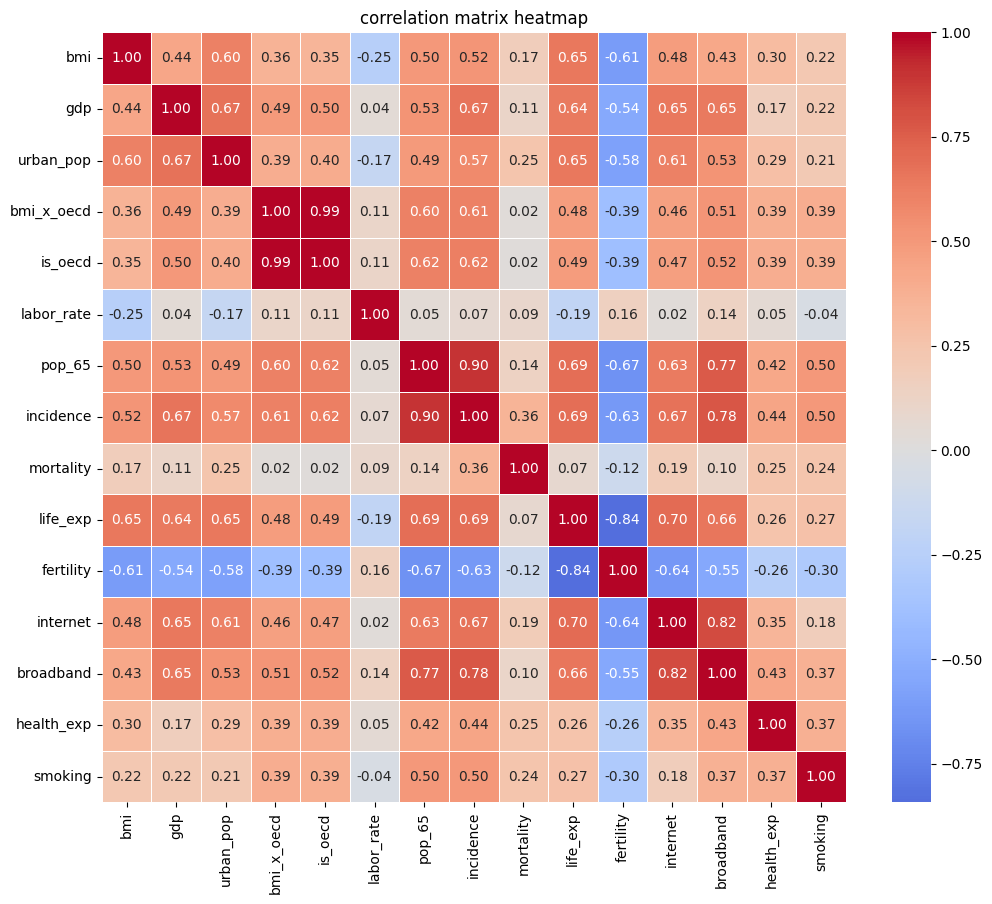

In [7]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())
columns_for_heatmap=['bmi', 'gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate', 'pop_65'
                      ,'incidence', 'mortality', 'life_exp', 'fertility','internet','broadband','health_exp','smoking']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()

# Dummy Variables: 

In [8]:
final_df['is_oecd']= final_df['country'].str.lower().str.strip().isin(oecd_countries).astype(int)
print(final_df['is_oecd'].value_counts())

is_oecd
0    3312
1     792
Name: count, dtype: int64


1. Aging Society Dummy: Based on WHO standards, societies with >10% population over 65 are considered "ageing" or "aged". This captures potential non-linear increases in cancer incidence due to population structure.

In [9]:
final_df['dm_high_aging_society'] = (final_df['pop_65'] > 10).astype(int)
print(final_df['dm_high_aging_society'].value_counts())

dm_high_aging_society
0    2762
1    1342
Name: count, dtype: int64


2. High Life Expectancy Dummy threshold of 75 years represents advanced healthcare systems and higher probability of disease detection.

In [10]:
final_df['dm_high_life_exp']=(final_df['life_exp']> 75).astype(int)
print(final_df['dm_high_life_exp'].value_counts())

dm_high_life_exp
1    2094
0    2010
Name: count, dtype: int64


In [11]:
comparison_inc= final_df.groupby('dm_high_life_exp').incidence.mean()
print(comparison_inc)

dm_high_life_exp
0    24.636303
1    90.325215
Name: incidence, dtype: float64


In [12]:
comparison_incid= final_df.groupby('dm_high_life_exp').incidence.mean()
print(comparison_incid)

dm_high_life_exp
0    24.636303
1    90.325215
Name: incidence, dtype: float64


In [13]:
print(final_df[['year', 'country', 'is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].head(100))

    year              country  is_oecd  dm_high_aging_society  \
0   2000                 fiji        0                      0   
1   2000             cambodia        0                      0   
2   2000             kiribati        0                      0   
3   2000           kazakhstan        0                      0   
4   2000              jamaica        0                      0   
..   ...                  ...      ...                    ...   
95  2000                spain        1                      1   
96  2000               cyprus        0                      0   
97  2000  antigua and barbuda        0                      0   
98  2001                malta        0                      1   
99  2001               canada        1                      1   

    dm_high_life_exp  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  
..               ...  
95                 1  
96                 1  
97          

# interaction of is_oecd variable and gdp

In [14]:
final_df['log_gdp']= np.log(final_df['gdp'])
final_df['log_gdp_is_oecd']= final_df['log_gdp']*final_df['is_oecd']
print(final_df['log_gdp_is_oecd'].head(5))

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: log_gdp_is_oecd, dtype: float64


In [15]:
final_df['is_oecd'] = 0
final_df.loc[final_df['country'].isin(oecd_countries), 'is_oecd'] = 1

# interaction of is_oecd variable and gdp
final_df['log_gdp'] = np.log(final_df['gdp'])
final_df['log_gdp_is_oecd'] = final_df['log_gdp'] * final_df['is_oecd']
# Filling NaNs in Interaction Term: Since 'NaN * 0 = NaN' in Python, rows where is_oecd is 0 but log_gdp is missing(NAN) 
# would incorrectly stay as NaN (and be counted in the results), then filled these with 0 to ensure only real OECD countries with data are counted.
final_df['log_gdp_is_oecd'] = final_df['log_gdp_is_oecd'].fillna(0)

# counting contries :
oecd_count = final_df[final_df['is_oecd'] == 1]['country'].nunique()
interaction_countries = final_df[final_df['log_gdp_is_oecd'] != 0]['country'].nunique()

In [16]:
print(final_df[['country','gdp','is_oecd','log_gdp_is_oecd','dm_high_aging_society', 'dm_high_life_exp']].sample(20).round(2))

               country       gdp  is_oecd  log_gdp_is_oecd  \
389           kiribati   2258.03        0             0.00   
1738        azerbaijan  19925.39        0             0.00   
4002          eswatini   9946.04        0             0.00   
4019  papua new guinea   4125.49        0             0.00   
2282              togo   2188.07        0             0.00   
955          greenland  55243.71        0             0.00   
3367    united kingdom  47144.72        1            10.76   
2458          bulgaria  25628.30        0             0.00   
2978             ghana   6234.51        0             0.00   
2681            malawi   1518.15        0             0.00   
231              benin   2630.18        0             0.00   
3460           albania  17112.94        0             0.00   
3266              fiji  11254.97        0             0.00   
919             zambia   2564.48        0             0.00   
3892            uganda   2791.06        0             0.00   
3479    

In [17]:
start_year=final_df['year'].min()
end_year=final_df['year'].max()
print(final_df[['year', 'country', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
start_count= final_df[final_df['year']== start_year]['dm_high_life_exp'].sum() 
end_count=final_df[final_df['year']== end_year]['dm_high_life_exp'].sum()
print(f"number of countries with high life_expectency in {start_count}")
print(f"number of countries with high life_expectency in {end_count}")

      year                   country  dm_high_aging_society  dm_high_life_exp
4004  2021                  zimbabwe                      0                 0
4005  2021  central african republic                      0                 0
4006  2021                   bahrain                      0                 1
4007  2021                madagascar                      0                 0
4008  2021                    malawi                      0                 0
...    ...                       ...                    ...               ...
4099  2023                    monaco                      1                 1
4100  2023                  dominica                      1                 0
4101  2023                 argentina                      1                 1
4102  2023        dominican republic                      0                 1
4103  2023                     nauru                      0                 0

[100 rows x 4 columns]
number of countries with high life_expec

# delet percentage of rows with missing value(NA):

In [18]:
# report of missing values
missing_report = (final_df.isnull().sum() / len(final_df)) * 100
print(missing_report[missing_report > 0])

gdp            3.265107
labor_rate     8.260234
internet       4.556530
broadband     16.301170
health_exp     6.505848
smoking       15.204678
log_gdp        3.265107
dtype: float64


In [19]:
clean_df= final_df.dropna(subset=['incidence','mortality', 'gdp', 'pop_65', 'urban_pop', 'life_exp', 'fertility', 'labor_rate', 'log_gdp_is_oecd', 'internet', 'broadband', 'health_exp', 'smoking'])
print(f" Missing values after deleting NA in clean_df: {clean_df.isnull().sum()}")

 Missing values after deleting NA in clean_df: country                  0
year                     0
incidence                0
mortality                0
gdp                      0
bmi                      0
pop_65                   0
urban_pop                0
life_exp                 0
fertility                0
labor_rate               0
internet                 0
broadband                0
health_exp               0
smoking                  0
is_oecd                  0
bmi_x_oecd               0
dm_high_aging_society    0
dm_high_life_exp         0
log_gdp                  0
log_gdp_is_oecd          0
dtype: int64


# Building stepwise regression

# Step 1: Adding Urban Population and log_gdp

In [20]:
df_step= clean_df.set_index(['country', 'year'])
exog_1_fe= sm.add_constant(df_step[['log_gdp', 'urban_pop']])
model_1_fe=PanelOLS(df_step['incidence'],exog_1_fe, entity_effects=True, time_effects=True).fit()
print(model_1_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0111
Estimator:                   PanelOLS   R-squared (Between):              0.1860
No. Observations:                2691   R-squared (Within):               0.1292
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.1792
Time:                        19:29:02   Log-likelihood                   -8544.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      14.176
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(2,2529)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             14.176
                            

# Step 2: Adding Pop_65:

In [21]:
exog_2_fe = df_step[['log_gdp', 'urban_pop', 'pop_65']]
model_2_fe = PanelOLS(df_step['incidence'], exog_2_fe, entity_effects=True, time_effects=True).fit()
print(model_2_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0376
Estimator:                   PanelOLS   R-squared (Between):              0.7218
No. Observations:                2691   R-squared (Within):               0.2959
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.7158
Time:                        19:29:02   Log-likelihood                   -8508.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      32.907
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(3,2528)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             32.907
                            

# Step 3: Adding Labor Rate:

In [22]:
exog_3_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate']])
model_3_fe=PanelOLS(df_step['incidence'], exog_3_fe, entity_effects=True, time_effects=True).fit()
print(model_3_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0377
Estimator:                   PanelOLS   R-squared (Between):              0.4133
No. Observations:                2691   R-squared (Within):               0.2936
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.4023
Time:                        19:29:03   Log-likelihood                   -8508.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      24.736
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(4,2527)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             24.736
                            

# Step 4: Adding BMI:

In [23]:
exog_4_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi']])
model_4_fe=PanelOLS(df_step['incidence'], exog_4_fe, entity_effects=True, time_effects= True).fit()
print(model_4_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0378
Estimator:                   PanelOLS   R-squared (Between):              0.4116
No. Observations:                2691   R-squared (Within):               0.2906
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.4007
Time:                        19:29:03   Log-likelihood                   -8508.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      19.836
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(5,2526)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             19.836
                            

# Step 5: Adding is_oecd as Dummy Variable:

In [24]:
exog_5_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd']])
model_5_fe=PanelOLS(df_step['incidence'], exog_5_fe, entity_effects=True, time_effects=True).fit()
print(model_5_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0413
Estimator:                   PanelOLS   R-squared (Between):             -0.5418
No. Observations:                2691   R-squared (Within):               0.2897
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.5604
Time:                        19:29:03   Log-likelihood                   -8503.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      18.140
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(6,2525)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             18.140
                            

# Step 6: Adding High aging society as Dummy Variable:

In [25]:
exog_6_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society']])
model_6_fe = PanelOLS(df_step['incidence'], exog_6_fe, entity_effects=True, time_effects=True).fit()
print(model_6_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0423
Estimator:                   PanelOLS   R-squared (Between):             -0.5380
No. Observations:                2691   R-squared (Within):               0.2941
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.5569
Time:                        19:29:03   Log-likelihood                   -8501.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      15.939
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(7,2524)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             15.939
                            

# Step 7: Adding High life exp as Dummy Variable:

In [26]:
exog_7_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society','dm_high_life_exp']])
model_7_fe = PanelOLS(df_step['incidence'], exog_7_fe, entity_effects=True, time_effects= True).fit()
print(model_7_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0437
Estimator:                   PanelOLS   R-squared (Between):             -0.4304
No. Observations:                2691   R-squared (Within):               0.3000
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.4492
Time:                        19:29:03   Log-likelihood                   -8499.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      14.408
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(8,2523)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             14.408
                            

# create labor_rate * is_oecd variable:

In [27]:
df_step['labor_rate * is_oecd']= df_step['labor_rate']* df_step['is_oecd']

# Step 8: Adding labor_rate * is_oecd:

In [28]:
exog_8_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi',
                                     'log_gdp_is_oecd', 'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd']])
model_8_fe = PanelOLS(df_step['incidence'], exog_8_fe, entity_effects=True, time_effects= True).fit()
print(model_8_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0571
Estimator:                   PanelOLS   R-squared (Between):             -0.0636
No. Observations:                2691   R-squared (Within):               0.2753
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.0767
Time:                        19:29:03   Log-likelihood                   -8480.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      16.971
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(9,2522)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             16.971
                            

# Step 9: Adding internet:

In [29]:
exog_9_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet']])
model_9_fe = PanelOLS(df_step['incidence'], exog_9_fe, entity_effects=True, time_effects= True).fit()
print(model_9_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1246
Estimator:                   PanelOLS   R-squared (Between):              0.2070
No. Observations:                2691   R-squared (Within):               0.5166
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.1982
Time:                        19:29:03   Log-likelihood                   -8380.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      35.884
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                 F(10,2521)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             35.884
                            

# Step  10: Adding broadband:

In [30]:
exog_10_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband']])
model_10_fe = PanelOLS(df_step['incidence'], exog_10_fe, entity_effects=True, time_effects= True).fit()
print(model_10_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1455
Estimator:                   PanelOLS   R-squared (Between):              0.2857
No. Observations:                2691   R-squared (Within):               0.5184
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.2796
Time:                        19:29:03   Log-likelihood                   -8348.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      39.005
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                 F(11,2520)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             39.005
                            

# Step  11: Adding smoking:

In [31]:
exog_11_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband','smoking']])
model_11_fe = PanelOLS(df_step['incidence'], exog_11_fe, entity_effects=True, time_effects= True).fit()
print(model_11_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1923
Estimator:                   PanelOLS   R-squared (Between):              0.6961
No. Observations:                2691   R-squared (Within):               0.4364
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.6871
Time:                        19:29:03   Log-likelihood                   -8272.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      49.983
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                 F(12,2519)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             49.983
                            

# step 12: adding health_exp:

In [32]:
exog_12_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd','dm_high_aging_society',
                                      'dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband','smoking','health_exp']])
model_12_fe = PanelOLS(df_step['incidence'], exog_12_fe, entity_effects=True, time_effects= True).fit()
print(model_12_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1953
Estimator:                   PanelOLS   R-squared (Between):              0.6592
No. Observations:                2691   R-squared (Within):               0.4246
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.6509
Time:                        19:29:04   Log-likelihood                   -8267.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      47.017
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                 F(13,2518)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             47.017
                            

# adding Fertality variable:

In [35]:
exog_13_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd','dm_high_aging_society',
                                      'dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband','smoking','health_exp','fertility']])
model_13_fe = PanelOLS(df_step['incidence'], exog_13_fe, entity_effects=True, time_effects= True).fit()
print(model_13_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.2008
Estimator:                   PanelOLS   R-squared (Between):              0.7423
No. Observations:                2691   R-squared (Within):               0.5032
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.7319
Time:                        19:32:44   Log-likelihood                   -8258.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      45.170
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                 F(14,2517)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             45.170
                            

# Comparing results of all Fixed Effect models:

In [36]:
Compare_results_fixed_Effect = compare({
    'FE model 1': model_1_fe,
    'FE model 2': model_2_fe,
    'FE model 3': model_3_fe,
    'FE model 4': model_4_fe,
    'FE model 5': model_5_fe,
    'FE model 6': model_6_fe,
    'FE model 7': model_7_fe,
    'FE model 8': model_8_fe,
    'FE model 9': model_9_fe,
    'FE model 10': model_10_fe,
    'FE model 11': model_11_fe,
    'FE model 12': model_12_fe,
    'FE model 13': model_13_fe
      })

print(Compare_results_fixed_Effect)

                                                                                                      Model Comparison                                                                                                      
                              FE model 1     FE model 2     FE model 3     FE model 4     FE model 5     FE model 6     FE model 7     FE model 8     FE model 9    FE model 10    FE model 11    FE model 12    FE model 13
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable                  incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence
Estimator                       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS 